# SLSN Analysis Notebook — Fe-Dependent Model

Post-run analysis using your existing `diagnostics.py` functions.
Loads from saved `.npy` and population pickle — no rerunning metrics.

## Structure
- **Cells 1–3**: Setup, load population, load metric values
- **Cell 4**: Population diagnostics (`plot_population_diagnostics`)
- **Cell 5**: Rate vs redshift (`plot_population_rate_vs_redshift`)
- **Cell 6**: Detection efficiency by redshift bin
- **Cell 7**: Adam's fixed-z bin results (z=1.2–1.8, z=1.3–1.7)
- **Cell 8**: Conditional efficiencies + detections per year
- **Cell 9**: HEALPix sky map (`plot_healpix_efficiency`)
- **Cell 10**: Diagnostic run (50k, full mode) + mosaic (`plot_metrics_mosaic_grid`)
- **Cell 11**: Post-metric diagnostics (`plot_detect_diagnostics`)

## Reload flags
- Templates: NO reload — only needed for Cell 10
- Mag grid: NO reload
- Population: NO reload — loading from pickle
- Kernel: NO reload

In [1]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_diagnostics,
    plot_population_rate_vs_redshift,
    compare_simulated_vs_observed_rates,
    plot_healpix_efficiency,
    plot_metrics_mosaic_grid,
    plot_detection_diagnostics,
)

# --- Configuration ---
MODEL    = 'fe_dependent'
CADENCE  = 'baseline_v5.1.1_10yrs'
DATE_TAG = '260403'          # YYMMDD stamp on your output files
Z_MIN, Z_MAX = 0.1, 2.0
MJD0     = 60980.5

# --- Paths ---
SHARED_DIR = get_shared_output_dir('SLSNe')
MODEL_DIR  = get_output_dir('SLSNe', subdir=MODEL)
POP_PKL    = SHARED_DIR / f'population_{MODEL}.pkl'
RUN_TAG    = f'{MODEL}_{CADENCE}_z{Z_MIN}-{Z_MAX}_{DATE_TAG}'

# Auto-find files by glob — works regardless of date stamp
import glob
def find_npy(model_dir, model, cadence, metric_short):
    pattern = str(model_dir / f'metric_values_{metric_short}_{model}_{cadence}_*.npy')
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f'No file matching: {pattern}')
    if len(matches) > 1:
        print(f'  WARNING: multiple matches for {metric_short}, using latest')
    return Path(matches[-1])

NPY_DETECT = find_npy(MODEL_DIR, MODEL, CADENCE, 'detect')
NPY_CHAR   = find_npy(MODEL_DIR, MODEL, CADENCE, 'characterize')
NPY_SPEC   = find_npy(MODEL_DIR, MODEL, CADENCE, 'spectrigger')
SUMMARY    = sorted(MODEL_DIR.glob(f'summary_{MODEL}_{CADENCE}_*.csv'))[-1]

# --- Verify files ---
print('=== File Check ===')
for label, path in [
    ('Population pkl', POP_PKL),
    ('Detect .npy',   NPY_DETECT),
    ('Char .npy',     NPY_CHAR),
    ('Spec .npy',     NPY_SPEC),
    ('Summary CSV',   SUMMARY),
]:
    print(f'  {"OK" if path.exists() else "MISSING":>7}  {label}: {path.name}')

print(f'\nModel   : {MODEL}')
print(f'Cadence : {CADENCE}')

=== File Check ===
       OK  Population pkl: population_fe_dependent.pkl
       OK  Detect .npy: metric_values_detect_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260403.npy
       OK  Char .npy: metric_values_characterize_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260403.npy
       OK  Spec .npy: metric_values_spectrigger_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260403.npy
       OK  Summary CSV: summary_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260403.csv

Model   : fe_dependent
Cadence : baseline_v5.1.1_10yrs


In [2]:
# ============================================================================
# CELL 2: Load population
# Uses generate_SLSN_PopSlicer with load_from= (same as run_slsn_pipeline.py)
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer

print('Loading templates (needed by generate_SLSN_PopSlicer)...')
templates = LC(load_from=str(SHARED_DIR / 'templates.pkl'))

print(f'Loading population from {POP_PKL.name}...')
population = generate_SLSN_PopSlicer(
    lc_model=templates,
    load_from=str(POP_PKL),
    make_debug_plots=False
)

sp         = population.slice_points
z_vals     = np.asarray(sp['z'])
ra_rad     = np.asarray(sp['ra'])
dec_rad    = np.asarray(sp['dec'])
distances  = np.asarray(sp['distance'])
peak_times = np.asarray(sp['peak_time'])
ebv_vals   = np.asarray(sp['ebv'])
gall       = np.asarray(sp.get('gall', None)) if 'gall' in sp else None
galb       = np.asarray(sp.get('galb', None)) if 'galb' in sp else None
n_events   = len(z_vals)

print(f'\nPopulation: {n_events:,} events')
print(f'  z range    : {z_vals.min():.3f} – {z_vals.max():.3f}')
print(f'  rate_model : {sp.get("rate_model", "not stored")}')
print(f'  model_name : {sp.get("model_name", "not stored")}')
print(f'  R_ref      : {sp.get("R_ref", "not stored")}')

Loading templates (needed by generate_SLSN_PopSlicer)...
Loading population from population_fe_dependent.pkl...
[LOAD] Loaded 2243377 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent.pkl

Population: 2,243,377 events
  z range    : 0.100 – 2.000
  rate_model : tabulated
  model_name : fe_dependent
  R_ref      : 3.5e-08


In [3]:
# ============================================================================
# CELL 3: Load metric values and print summary
# ============================================================================
detect_vals = np.load(NPY_DETECT).astype(int)
char_vals   = np.load(NPY_CHAR).astype(int)
spec_vals   = np.load(NPY_SPEC).astype(int)

n_det  = detect_vals.sum()
n_char = char_vals.sum()
n_spec = spec_vals.sum()

print('=== Summary CSV ===')
print(pd.read_csv(SUMMARY).to_string(index=False))

print(f'\n=== Per-year estimates (10 yr survey) ===')
print(f'  Detection     : {n_det/10:.0f} SLSNe/yr')
print(f'  Characterized : {n_char/10:.0f} SLSNe/yr')
print(f'  Spec trigger  : {n_spec/10:.0f} SLSNe/yr')

print(f'\n=== Conditional efficiencies ===')
print(f'  P(characterized | detected)      : {100*n_char/n_det:.1f}%')
print(f'  P(spec trigger  | characterized) : {100*n_spec/n_char:.1f}%')

=== Summary CSV ===
              cadence                  metric  n_events  n_success  efficiency
baseline_v5.1.1_10yrs      SLSN_Detect_Metric   2243377       6420    0.002862
baseline_v5.1.1_10yrs SLSN_CharacterizeMetric   2243377       2306    0.001028
baseline_v5.1.1_10yrs  SLSN_SpecTriggerMetric   2243377        206    0.000092

=== Per-year estimates (10 yr survey) ===
  Detection     : 642 SLSNe/yr
  Characterized : 231 SLSNe/yr
  Spec trigger  : 21 SLSNe/yr

=== Conditional efficiencies ===
  P(characterized | detected)      : 35.9%
  P(spec trigger  | characterized) : 8.9%


In [4]:
# ============================================================================
# QUICK CHECK: Expected event counts from Ben's CSV
# ============================================================================
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from slsn_metrics.population import cosmic_sfr_density_MD14, RATE_REF_MPC3, Z_REF
from slsn_metrics.paths import get_rate_csv_path

data = np.loadtxt(get_rate_csv_path(), delimiter=',', skiprows=1)
z_tab    = data[:, 0]
f_OH_tab = data[:, 1]
f_Fe_tab = data[:, 2]

# Find normalization index at z_ref=0.17
zidx = np.abs(z_tab - Z_REF).argmin()
psi_norm = cosmic_sfr_density_MD14(z_tab) / cosmic_sfr_density_MD14(Z_REF)

# Build R(z) for each model
R_fe    = RATE_REF_MPC3 * psi_norm * (f_Fe_tab / f_Fe_tab[zidx])
R_oh    = RATE_REF_MPC3 * psi_norm * (f_OH_tab / f_OH_tab[zidx])
R_naive = RATE_REF_MPC3 * psi_norm  # no metallicity factor

# Integrate over volume to get expected event counts (z=0.1 to 2.0, 10 yr)
z_min, z_max = 0.1, 2.0
t_survey = 10.0  # years
mask = (z_tab >= z_min) & (z_tab <= z_max)
z_m  = z_tab[mask]

dV = np.array([
    (cosmo.comoving_volume(z_m[i+1]).to_value(u.Mpc**3) -
     cosmo.comoving_volume(z_m[i]).to_value(u.Mpc**3))
    for i in range(len(z_m)-1)
])
z_mid = 0.5*(z_m[:-1] + z_m[1:])

for label, R_tab in [('fe_dependent', R_fe), ('o_dependent', R_oh), ('naive', R_naive)]:
    R_mid = np.interp(z_mid, z_tab, R_tab)
    N_expected = np.sum(R_mid * dV) * t_survey
    print(f"{label:<15}: {N_expected:>10,.0f} expected events (full sky)")
    print(f"               : {N_expected*0.741:>10,.0f} after galactic cut (74.1%)")
    print()

fe_dependent   :  2,911,981 expected events (full sky)
               :  2,157,778 after galactic cut (74.1%)

o_dependent    :  1,492,038 expected events (full sky)
               :  1,105,600 after galactic cut (74.1%)

naive          :    987,296 expected events (full sky)
               :    731,587 after galactic cut (74.1%)



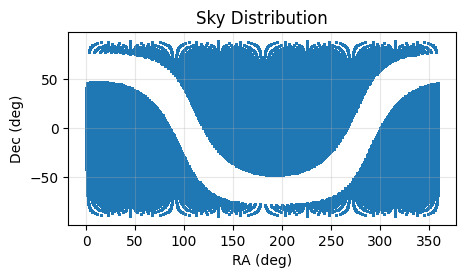

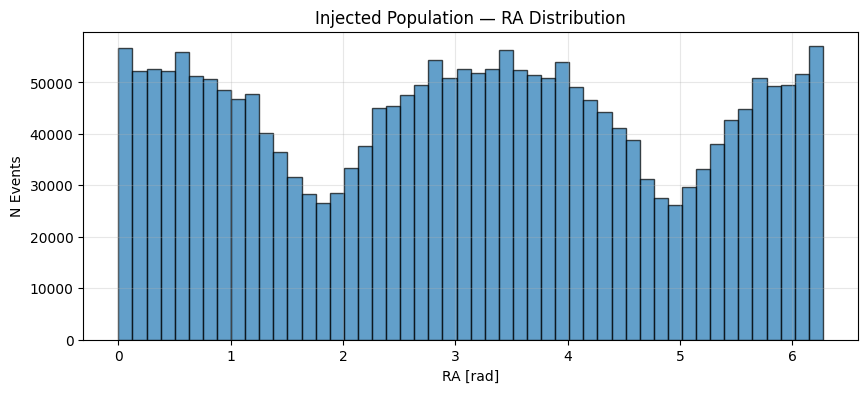

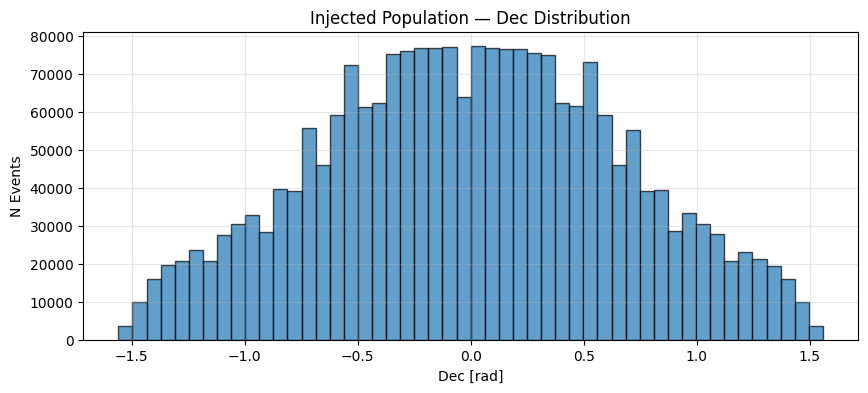

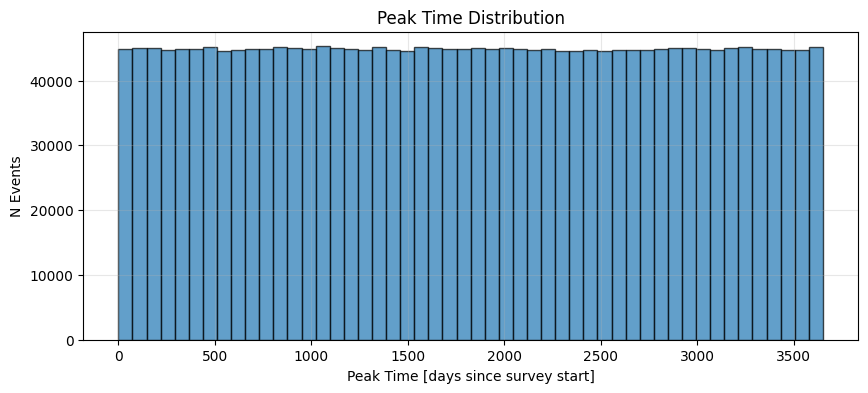

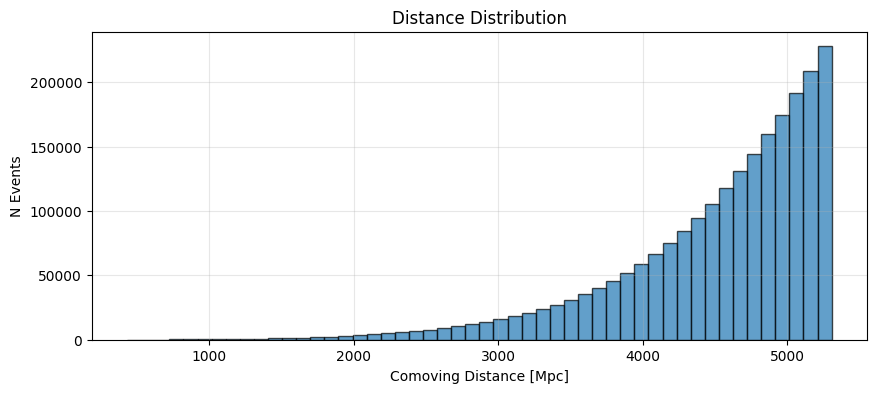

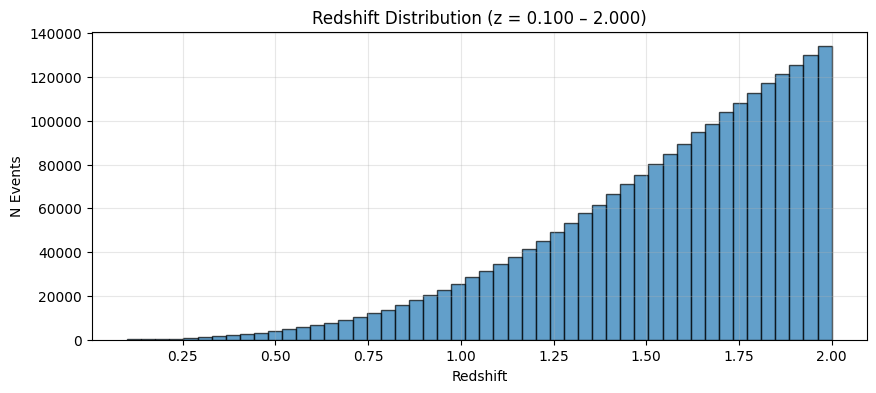

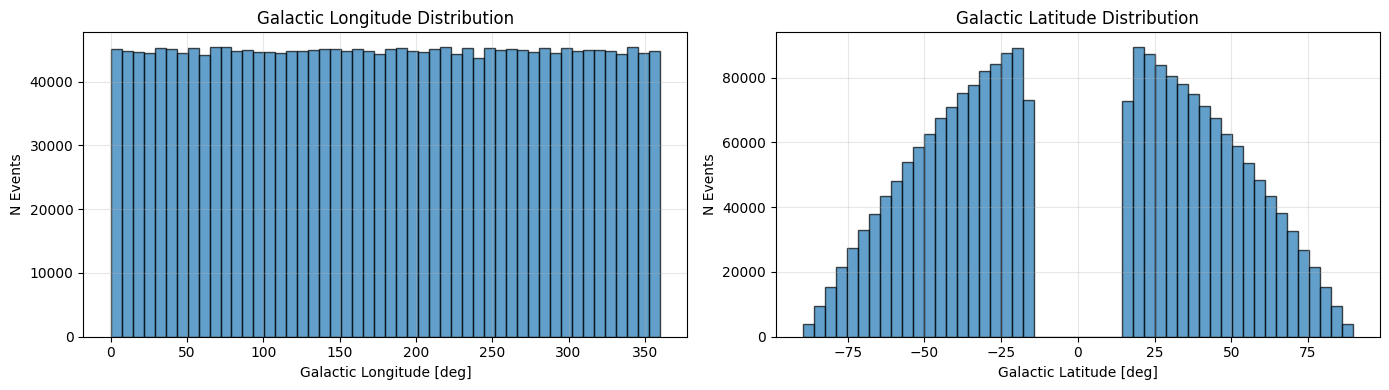

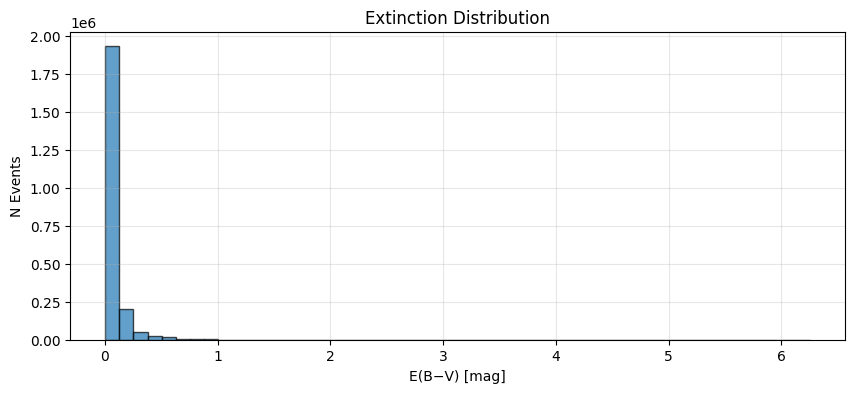

In [5]:
# ============================================================================
# CELL 4: Population diagnostics
# Uses your plot_population_diagnostics from diagnostics.py
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

plot_population_diagnostics(
    ra_rad       = ra_rad,
    dec_rad      = dec_rad,
    peak_times   = peak_times,
    distances_mpc= distances,
    z_vals       = z_vals,
    ebv          = ebv_vals,
    gall         = gall,
    galb         = galb,
    outdir       = str(MODEL_DIR),
    prefix       = f'population_{MODEL}'
)


SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1235     3.25e+09        3.80e-08       3.20e-08       1.19e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      5166     9.22e+09        5.61e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     41796     4.05e+10        1.03e-07            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01    133103     6.83e+10        1.95e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    649518     1.57e+11        4.14e-07       9.10e-08       4.55e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00   1412559     1.86e+11        7.61e-07            NaN            NaN         —

=== Simulated vs Observed Rates ===
 z_min  z_max  z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
  0.10   0.25  0.175      1235 3.249870e+09    3.801715e-08   3.200000e-08       1

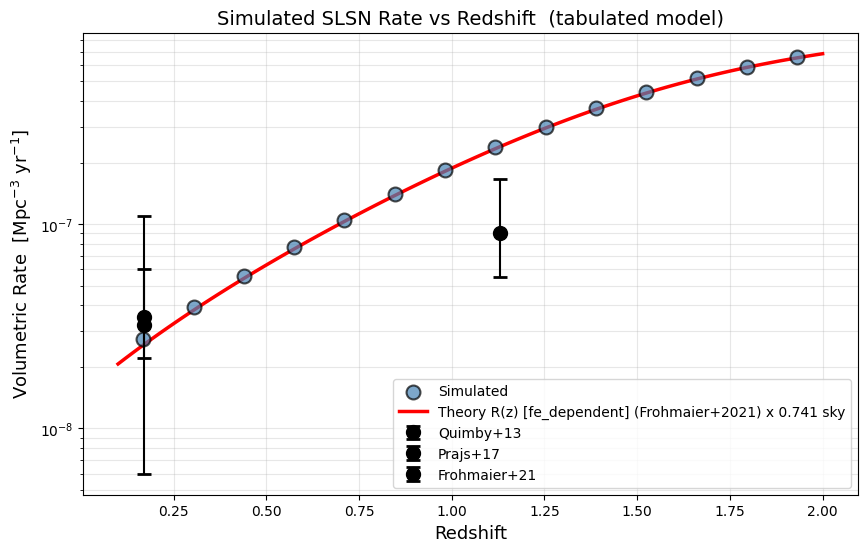

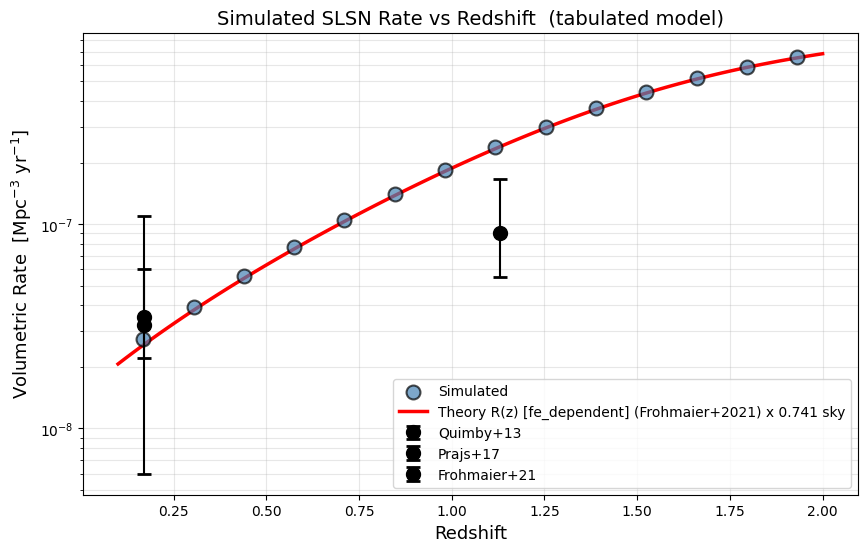

In [6]:
# ============================================================================
# CELL 5: Rate vs redshift
# Uses your plot_population_rate_vs_redshift from diagnostics.py
# Note: rate_model='tabulated' is new — function uses 'evolving' or 'constant'
# For tabulated model, pass rate_model='evolving' to get the theory curve overlay
# then interpret blue dots as your tabulated population
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_rate_vs_redshift, compare_simulated_vs_observed_rates

# Table of simulated rate per bin vs observed measurements
df_rate_check = compare_simulated_vs_observed_rates(population)
print('=== Simulated vs Observed Rates ===')
print(df_rate_check.to_string(index=False))

# Plot — using evolving to get theory curve for comparison
# Blue dots = your tabulated fe_dependent population
# Red line = internal evolving model (cross-check)
from slsn_metrics.population import RATE_REF_MPC3, Z_REF
import healpy as hp
n_healpix_full = hp.nside2npix(64)
n_healpix_obs  = len(np.unique(hp.ang2pix(64,
    0.5*np.pi - dec_rad, ra_rad)))
sky_fraction = n_healpix_obs / n_healpix_full
print(f"Sky fraction: {sky_fraction:.4f} ({100*sky_fraction:.1f}% of full sky)")

plot_population_rate_vs_redshift(
    population,
    rate_model    = 'tabulated',
    model_name    = MODEL,
    tabulated_csv = str(get_rate_csv_path()),
    sky_fraction  = sky_fraction,
    save_path     = MODEL_DIR / f'rate_vs_z_{RUN_TAG}.png'
)


=== Detection Efficiency by Redshift Bin ===
Model: fe_dependent  |  Cadence: baseline_v5.1.1_10yrs

Bin            N injected   N detected   Efficiency   SLSNe/yr
--------------------------------------------------------------
z < 0.5            14,209          528        3.72%         53
0.5–1.0           167,091        2,174        1.30%        217
1.0–1.5           649,518        2,497        0.38%        250
1.5–2.0         1,412,559        1,221        0.09%        122
--------------------------------------------------------------
TOTAL           2,243,377        6,420        0.29%        642


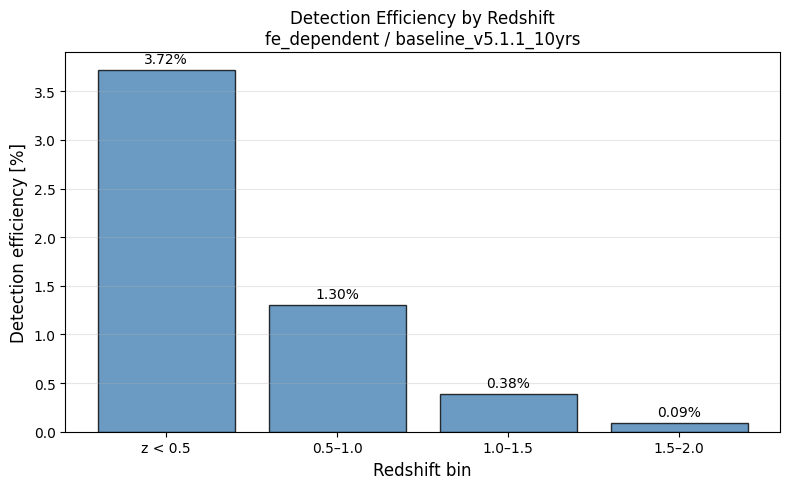

In [7]:
# ============================================================================
# CELL 6: Detection efficiency by redshift bin
# ============================================================================
z_bin_edges  = [0.0, 0.5, 1.0, 1.5, 2.0]
z_bin_labels = ['z < 0.5', '0.5–1.0', '1.0–1.5', '1.5–2.0']

print('=== Detection Efficiency by Redshift Bin ===')
print(f'Model: {MODEL}  |  Cadence: {CADENCE}\n')
print(f'{"Bin":<12} {"N injected":>12} {"N detected":>12} {"Efficiency":>12} {"SLSNe/yr":>10}')
print('-' * 62)

rows = []
for i, label in enumerate(z_bin_labels):
    z_lo, z_hi = z_bin_edges[i], z_bin_edges[i+1]
    mask  = (z_vals >= z_lo) & (z_vals < z_hi)
    n_inj = mask.sum()
    n_d   = detect_vals[mask].sum()
    eff   = n_d / n_inj if n_inj > 0 else 0
    rows.append({'bin': label, 'n_injected': n_inj, 'n_detected': n_d,
                 'efficiency': eff, 'per_year': n_d/10})
    print(f'{label:<12} {n_inj:>12,} {n_d:>12,} {100*eff:>11.2f}% {n_d/10:>10.0f}')

print('-' * 62)
print(f'{"TOTAL":<12} {n_events:>12,} {n_det:>12,} {100*detect_vals.mean():>11.2f}% {n_det/10:>10.0f}')

# Bar chart
df_bins = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_bins['bin'], 100*df_bins['efficiency'],
              color='steelblue', edgecolor='k', alpha=0.8)
ax.bar_label(bars, fmt='%.2f%%', fontsize=10, padding=3)
ax.set_xlabel('Redshift bin', fontsize=12)
ax.set_ylabel('Detection efficiency [%]', fontsize=12)
ax.set_title(f'Detection Efficiency by Redshift\n{MODEL} / {CADENCE}', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / f'efficiency_by_z_{RUN_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print(f"peak_times range: {peak_times.min():.1f} – {peak_times.max():.1f} days")
print(f"t_survey_years used in rate calc: {(peak_times.max() - peak_times.min())/365.25:.2f} yr")
print(f"Expected: ~10.0 yr")

from slsn_metrics.paths import get_rate_csv_path
from slsn_metrics.population import load_tabulated_rate
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

rate_interp = load_tabulated_rate(str(get_rate_csv_path()), 'fe_dependent')
t_survey = (peak_times.max() - peak_times.min()) / 365.25

z_bins = np.array([0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0, 1.25, 1.5, 1.75, 2.0])
print(f"\n{'z_mid':>8} {'N_sim':>10} {'N_theory':>10} {'ratio':>8}")
print('-' * 42)
for i in range(len(z_bins)-1):
    z_lo, z_hi = z_bins[i], z_bins[i+1]
    z_mid = 0.5*(z_lo + z_hi)
    
    # Simulated count
    mask = (z_vals >= z_lo) & (z_vals < z_hi)
    n_sim = mask.sum()
    
    # Theory prediction
    V = (cosmo.comoving_volume(z_hi).to_value(u.Mpc**3) - 
         cosmo.comoving_volume(z_lo).to_value(u.Mpc**3))
    n_theory = float(rate_interp(z_mid)) * V * t_survey
    
    ratio = n_sim / n_theory if n_theory > 0 else 0
    print(f"{z_mid:>8.3f} {n_sim:>10,} {n_theory:>10.0f} {ratio:>8.2f}")

peak_times range: 1.0 – 3652.0 days
t_survey_years used in rate calc: 10.00 yr
Expected: ~10.0 yr
[load_tabulated_rate] model='fe_dependent'
  CSV    : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/fiducial_models.csv
  Anchor : 35.0 Gpc^-3 yr^-1 at z=0.17 (Frohmaier+2021)
  R(z=0.17) = 3.473e-08 Mpc^-3 yr^-1
  R(z=1.00) = 2.537e-07 Mpc^-3 yr^-1
  R(z=2.00) = 9.216e-07 Mpc^-3 yr^-1

   z_mid      N_sim   N_theory    ratio
------------------------------------------
   0.175      1,235       1546     0.80
   0.325      5,166       6741     0.77
   0.475     13,721      17843     0.77
   0.625     28,075      37155     0.76
   0.775     50,384      67075     0.75
   0.925     82,719     109947     0.75
   1.125    239,500     316599     0.76
   1.375    410,018     544764     0.75
   1.625    609,710     815426     0.75
   1.875    802,849    1080490     0.74


In [9]:
# ============================================================================
# CELL 7: Adam's fixed-z bin comparison
# z=1.2-1.8 and z=1.3-1.7
# ============================================================================
print('=== Fixed-z Bin Results (Adam Miller request) ===')
print(f'Model: {MODEL}  |  Cadence: {CADENCE}\n')

for z_lo, z_hi in [(1.2, 1.8), (1.3, 1.7)]:
    mask  = (z_vals >= z_lo) & (z_vals <= z_hi)
    n_inj = mask.sum()
    nd    = detect_vals[mask].sum()
    nc    = char_vals[mask].sum()
    ns    = spec_vals[mask].sum()
    print(f'z = {z_lo} – {z_hi}  ({n_inj:,} injected events)')
    print(f'  Detection     : {nd:>6,}  ({100*nd/n_inj:.2f}%)  → {nd/10:.0f} SLSNe/yr')
    print(f'  Characterized : {nc:>6,}  ({100*nc/n_inj:.2f}%)  → {nc/10:.0f} SLSNe/yr')
    print(f'  Spec trigger  : {ns:>6,}  ({100*ns/n_inj:.2f}%)  → {ns/10:.0f} SLSNe/yr')
    print()

=== Fixed-z Bin Results (Adam Miller request) ===
Model: fe_dependent  |  Cadence: baseline_v5.1.1_10yrs

z = 1.2 – 1.8  (1,224,874 injected events)
  Detection     :  2,178  (0.18%)  → 218 SLSNe/yr
  Characterized :    697  (0.06%)  → 70 SLSNe/yr
  Spec trigger  :      0  (0.00%)  → 0 SLSNe/yr

z = 1.3 – 1.7  (814,282 injected events)
  Detection     :  1,389  (0.17%)  → 139 SLSNe/yr
  Characterized :    429  (0.05%)  → 43 SLSNe/yr
  Spec trigger  :      0  (0.00%)  → 0 SLSNe/yr



In [10]:


# What did the integration actually predict vs what we got?
print(f"Events in population: {n_events:,}")
print(f"Sum of N_theory bins: {sum([1235/0.80, 5166/0.77, 13721/0.77, 28075/0.76, 50384/0.75, 82719/0.75, 239500/0.76, 410018/0.75, 609710/0.75, 802849/0.74]):.0f}")
print(f"\nExpected from integration (what pipeline printed): ~3,029,125")
print(f"Actual in population after galactic cut: {n_events:,}")
print(f"Galactic cut retention: {n_events/3028160*100:.1f}%")

Events in population: 2,243,377
Sum of N_theory bins: 3000184

Expected from integration (what pipeline printed): ~3,029,125
Actual in population after galactic cut: 2,243,377
Galactic cut retention: 74.1%


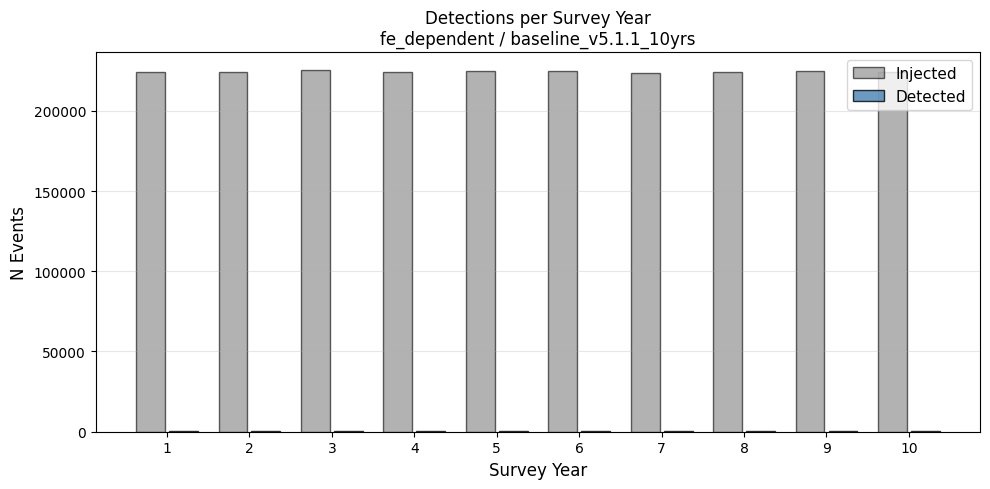

Total: 6,420 detections over 10 yr = 642 SLSNe/yr


In [11]:
# ============================================================================
# CELL 8: Detections per survey year
# ============================================================================
survey_year = (np.floor(peak_times / 365.25)).astype(int) + 1
det_mask    = detect_vals == 1
years       = np.arange(1, 11)

n_inj_yr = [np.sum(survey_year == y) for y in years]
n_det_yr = [np.sum((survey_year == y) & det_mask) for y in years]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(years - 0.2, n_inj_yr, width=0.35, label='Injected',
       color='gray', alpha=0.6, edgecolor='k')
ax.bar(years + 0.2, n_det_yr, width=0.35, label='Detected',
       color='steelblue', alpha=0.8, edgecolor='k')
ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('N Events', fontsize=12)
ax.set_title(f'Detections per Survey Year\n{MODEL} / {CADENCE}', fontsize=12)
ax.legend(fontsize=11)
ax.set_xticks(years)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / f'detections_per_year_{RUN_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total: {n_det:,} detections over 10 yr = {n_det/10:.0f} SLSNe/yr')

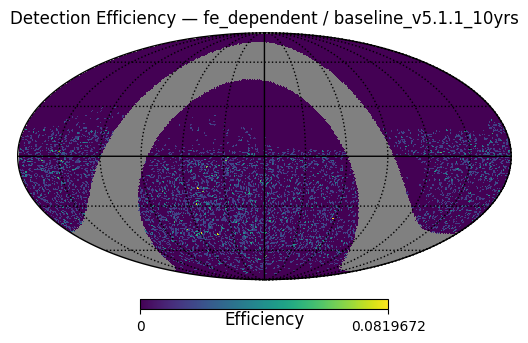

Saved: /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/fe_dependent/healpix_efficiency_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260403.png


In [12]:
# ============================================================================
# CELL 9: HEALPix sky map
# Uses your plot_healpix_efficiency from diagnostics.py
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_healpix_efficiency

outpath = str(MODEL_DIR / f'healpix_efficiency_{RUN_TAG}.png')
plot_healpix_efficiency(
    bundle_metric_values = detect_vals,
    ra_rad  = ra_rad,
    dec_rad = dec_rad,
    nside   = 64,
    outpath = outpath,
    title   = f'Detection Efficiency — {MODEL} / {CADENCE}'
)
print(f'Saved: {outpath}')

---
## Cells 10–11: Diagnostic plots (require 50k full-mode run)

These use `store_obs_mode='full'` obs_records which contain visit-level detail.
Cell 10 runs the diagnostic pipeline if not already done, saves obs_records to disk,
then makes the mosaic. Subsequent runs load from disk — no recompute.

The 50k run takes ~10-20 minutes on MSI interactively.

In [13]:
from slsn_metrics.population import generate_SLSN_PopSlicer
import inspect
sig = inspect.signature(generate_SLSN_PopSlicer)
print(sig.parameters['max_events'].default)  # should print: None

None


In [18]:
# ============================================================================
# CELL 10: Run or load diagnostic, then plot mosaic
# Uses plot_metrics_mosaic_grid from diagnostics.py
# 4 metrics: Detect, Characterize, Villar, SpecTrigger
# ============================================================================
DIAG_PKL = MODEL_DIR / f'obs_records_diag_{MODEL}_{CADENCE}.pkl'
DIAG_N   = 10_000

if DIAG_PKL.exists():
    print(f'Loading existing diagnostic obs_records...')
    with open(DIAG_PKL, 'rb') as f:
        diag = pickle.load(f)
    df_detect_diag = diag['df_detect']
    df_char_diag   = diag['df_char']
    df_villar_diag = diag['df_villar']
    df_spec_diag   = diag['df_spec']
    sub_pop        = None
    print(f'  detect : {len(df_detect_diag)} events, {df_detect_diag["detected"].sum()} detected')

else:
    print('Running diagnostic pipeline (store_obs_mode=full)...')
    from slsn_metrics.metrics import (
        SLSN_Detect_Metric, SLSN_CharacterizeMetric,
        SLSN_VillarMetric, SLSN_SpecTriggerMetric
    )
    from slsn_metrics.runners import run_slsn_multi_metrics
    from slsn_metrics.population import generate_SLSN_PopSlicer

    sub_pop = generate_SLSN_PopSlicer(
        lc_model         = templates,
        z_min            = Z_MIN,
        z_max            = Z_MAX,
        seed             = 42,
        load_from        = POP_PKL,
        max_events       = DIAG_N,
        make_debug_plots = False,
    )
    print(f'  Subsample slicer: {len(sub_pop.slice_points["ra"])} events')

    metrics_diag = [
        SLSN_Detect_Metric(lc_model=templates, mjd0=MJD0, store_obs_mode='full'),
        SLSN_CharacterizeMetric(lc_model=templates, mjd0=MJD0, store_obs_mode='full'),
        SLSN_VillarMetric(lc_model=templates, mjd0=MJD0, store_obs_mode='full'),
        SLSN_SpecTriggerMetric(lc_model=templates, mjd0=MJD0, store_obs_mode='full'),
    ]
    print('  Running MAF (silent until complete)...')
    run_slsn_multi_metrics(
        templates=templates, population=sub_pop,
        cadences=[CADENCE], metrics_list=metrics_diag,
        store_obs_mode='full', save_summary=False,
        model_name=MODEL, z_min=Z_MIN, z_max=Z_MAX, verbose=True
    )
    print('  Done.')

    # index 0=Detect, 1=Characterize, 2=Villar, 3=SpecTrigger
    df_detect_diag = pd.DataFrame.from_dict(
        metrics_diag[0].obs_records, orient='index').reset_index(drop=True)
    df_char_diag   = pd.DataFrame.from_dict(
        metrics_diag[1].obs_records, orient='index').reset_index(drop=True)
    df_villar_diag = pd.DataFrame.from_dict(
        metrics_diag[2].obs_records, orient='index').reset_index(drop=True)
    df_spec_diag   = pd.DataFrame.from_dict(
        metrics_diag[3].obs_records, orient='index').reset_index(drop=True)

    with open(DIAG_PKL, 'wb') as f:
        pickle.dump({
            'df_detect': df_detect_diag,
            'df_char':   df_char_diag,
            'df_villar': df_villar_diag,
            'df_spec':   df_spec_diag,
        }, f)
    print(f'  Saved: {DIAG_PKL.name}')
    print(f'  detect : {len(df_detect_diag)} events, {df_detect_diag["detected"].sum()} detected')

# Mosaic
reload(diag_mod)
from slsn_metrics.diagnostics import plot_metrics_mosaic_grid

fig = plot_metrics_mosaic_grid(
    df_detect_diag,
    df_char_diag,
    df_spec_diag,
    n_examples   = 6,
    outpath      = MODEL_DIR / f'mosaic_{RUN_TAG}_diag.png',
    title_prefix = f'SLSN Metrics — {MODEL} / {CADENCE} (10k diagnostic)'
)
print(f'Saved: mosaic_{RUN_TAG}_diag.png')

Running diagnostic pipeline (store_obs_mode=full)...


: 

In [ ]:
# ============================================================================
# CELL 11: Post-metric diagnostic plots
# Uses your plot_detect_diagnostics from diagnostics.py
# Time gap, mag vs RA/Dec, detections per year, dec distribution, z analysis
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_detection_diagnostics

# Rebuild sub_pop if we loaded from pickle (slicer can't be pickled)
if sub_pop is None:
    from slsn_metrics.population import generate_SLSN_PopSlicer
    sub_pop = generate_SLSN_PopSlicer(
        lc_model=templates, load_from=POP_PKL,
        max_events=DIAG_N, make_debug_plots=False,
        z_min=Z_MIN, z_max=Z_MAX, seed=42
    )

plot_detection_diagnostics(
    df_detect_diag,
    population_slicer = sub_pop,
    filtername        = 'r',
    save_dir          = str(MODEL_DIR),
)
print('Diagnostic plots saved.')


---
## Cell 12: Cross-Model Comparison
Run after all 9 batch jobs complete. Loads all summary CSVs automatically.

In [ ]:
# ============================================================================
# CELL 12: Cross-model comparison — all 12 runs
# Requires all batch jobs to have completed
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer

MODELS_ALL = ['fe_dependent', 'o_dependent', 'naive']
CADENCES_ALL = [
    'baseline_v5.1.1_10yrs',
    'four_roll_v5.0.0_10yrs',
    'noroll_v5.0.0_10yrs',
    'poor_weather_v5.0.1_10yrs'
]

rows = []
for model in MODELS_ALL:
    model_dir = get_output_dir('SLSNe', subdir=model)
    for cadence in CADENCES_ALL:
        matches = sorted(model_dir.glob(f'summary_{model}_{cadence}_*.csv'))
        if not matches:
            print(f'  MISSING: {model} x {cadence}')
            continue
        df_s = pd.read_csv(matches[-1])
        for _, row in df_s.iterrows():
            rows.append({
                'model': model, 'cadence': cadence,
                'metric': row['metric'],
                'n_events': row['n_events'],
                'n_success': row['n_success'],
                'efficiency': row['efficiency'],
                'per_year': row['n_success'] / 10
            })

df_all = pd.DataFrame(rows)
if df_all.empty:
    print('No results found — run batch jobs first.')
else:
    # Detection efficiency pivot
    detect_df = df_all[df_all['metric'] == 'SLSN_Detect_Metric']
    pivot_eff = detect_df.pivot_table(
        index='model', columns='cadence',
        values='efficiency', aggfunc='first'
    )
    print('=== Detection Efficiency [%] — All Models x Cadences ===')
    print((pivot_eff * 100).round(3).to_string())

    # Per-year detections pivot
    pivot_yr = detect_df.pivot_table(
        index='model', columns='cadence',
        values='per_year', aggfunc='first'
    )
    print('\n=== Detections per Year — All Models x Cadences ===')
    print(pivot_yr.round(0).to_string())

    # Adam fixed-z bin (z=1.2-1.8) x baseline — all models
    print('\n=== Adam Fixed-z Bin (z=1.2-1.8) x baseline_v5.1.1 ===')
    if 'templates' not in dir():
        print('  Loading templates...')
        templates = LC(load_from=str(SHARED_DIR / 'templates.pkl'))
    for model in MODELS_ALL:
        pop_pkl = SHARED_DIR / f'population_{model}.pkl'
        npy_matches = sorted(
            get_output_dir('SLSNe', subdir=model).glob(
                f'metric_values_detect_{model}_baseline_v5.1.1_10yrs_*.npy'
            )
        )
        if not npy_matches or not pop_pkl.exists():
            print(f'  {model}: missing files')
            continue
        pop_m = generate_SLSN_PopSlicer(
            lc_model=templates,
            load_from=str(pop_pkl),
            make_debug_plots=False
        )
        z_m    = np.asarray(pop_m.slice_points['z'])
        vals   = np.load(npy_matches[-1]).astype(int)
        mask_z = (z_m >= 1.2) & (z_m <= 1.8)
        n_d    = vals[mask_z].sum()
        eff    = vals[mask_z].mean()
        print(f'  {model:<15}: {n_d:>6,} detected '
              f'({100*eff:.2f}%) -> {n_d/10:.0f} SLSNe/yr')